In [1]:
%run init.ipynb
%run entropy.ipynb
%run ptr.ipynb
%run jupyterQ.ipynb

import qiskit

from qiskit import *

In [2]:
from qiskit import IBMQ
IBMQ.save_account('407eee087e66afb971221353c2214710f90034665067ef91fefb09e98c6c99d94ff4f4f1c14131a196c09a5d24a4368e1aaa03b0f3d99578f0b8f47071995da6', overwrite = True)
qiskit.IBMQ.load_account()
provider = qiskit.IBMQ.get_provider(hub='ibm-q', group='open', project='main')
from qiskit.tools.monitor import backend_overview, backend_monitor


In [3]:
backend_overview()

ibmq_manila                  ibmq_quito                   ibmq_lima
-----------                  ----------                   ---------
Num. Qubits:  5              Num. Qubits:  5              Num. Qubits:  5
Pending Jobs: 9              Pending Jobs: 1              Pending Jobs: 2
Least busy:   False          Least busy:   True           Least busy:   False
Operational:  True           Operational:  True           Operational:  True
Avg. T1:      139.4          Avg. T1:      110.6          Avg. T1:      95.0
Avg. T2:      62.0           Avg. T2:      133.6          Avg. T2:      119.7



ibmq_bogota                  ibmq_santiago                ibmq_armonk
-----------                  -------------                -----------
Num. Qubits:  5              Num. Qubits:  5              Num. Qubits:  1
Pending Jobs: 18             Pending Jobs: 5              Pending Jobs: 3
Least busy:   False          Least busy:   False          Least busy:   False
Operational:  True           Operatio

In [4]:
device = provider.get_backend('ibmq_armonk')

from qiskit.tools.monitor import job_monitor
qr = QuantumRegister(1)
qc = qiskit.QuantumCircuit(qr); 
qc_cal = qiskit.QuantumCircuit(qr)
from qiskit.ignis.mitigation.measurement import (complete_meas_cal, CompleteMeasFitter)
cal_circuits, state_labels = complete_meas_cal(qr = qc.qregs[0], circlabel = 'mmc')
cal_job = execute(cal_circuits, backend = device, shots = 8192, optimization_level = 0)
print(cal_job.job_id())
job_monitor(cal_job)
cal_results = cal_job.result()
meas_fitter = CompleteMeasFitter(cal_results, state_labels)
meas_filter = meas_fitter.filter

6241de0598d40bd568d97563
Job Status: job has successfully run


In [5]:
from qiskit.tools.monitor import job_monitor
from qiskit.ignis.verification.tomography import state_tomography_circuits, StateTomographyFitter
from qiskit.ignis.mitigation.measurement import (complete_meas_cal, CompleteMeasFitter)

nshots = 8192

### Mach-Zehnder com BS1 balanceado $T = R = 1/\sqrt{2}$


<img src="prep1.png" width="500">


In [18]:
def qc_mzi_sim(ph): # quantum circuit for the Mach-Zehnder interferometer
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc.u(math.pi/2, math.pi/2, -math.pi/2, qr[0]); # DF
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    qc.z(qr[0]); qc.y(qr[0]) # espelho
    qc.p(ph, qr[0]); # fase
    qc.u(math.pi/2, math.pi/2, -math.pi/2, qr[0]) # DF
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    return qc
qcmzi = qc_mzi_sim(math.pi/8); qcmzi.draw()



┌─────────────────┐┌───┐┌───┐┌────────┐┌─────────────────┐
q64_0: ┤ U(π/2,π/2,-π/2) ├┤ Z ├┤ Y ├┤ P(π/8) ├┤ U(π/2,π/2,-π/2) ├
       └─────────────────┘└───┘└───┘└────────┘└─────────────────┘

In [19]:
def state_prep(th, ph):
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc.u(th, ph, 0, qr[0])
    return qc



In [22]:
phmax = 2*math.pi; dph = phmax/20; ph = np.arange(0, phmax+dph, dph)#; ph
d = ph.shape[0]; PD0teo = np.zeros(d); PD0sim = np.zeros(d); PD0exp = np.zeros(d)
for j in range(0, d):
    PD0teo[j] = (1+math.cos(ph[j]))/2 # theoretical
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc_sp = state_prep(0, 0); qc.append(qc_sp, [qr[0]]) # state preparation (estado |0>)
    qc_mzi = qc_mzi_sim(ph[j]); qc.append(qc_mzi, [qr[0]]) # apply sim mzi 
    qstc = state_tomography_circuits(qc, qr[0]) # circuit for state tomography
    job = qiskit.execute(qstc, Aer.get_backend('qasm_simulator'), shots=nshots)
    qstf = StateTomographyFitter(job.result(), qstc); rho = qstf.fit(method='lstsq')
    PD0sim[j] = rho[0,0].real
    # 1º fiz as simulações, só depois adicionei o código para os experimentos
    #job = qiskit.execute(qstc, backend = device, shots = nshots)
    #print(job.job_id()); job_monitor(job)
    #qstf = StateTomographyFitter(job.result(), qstc); rho = qstf.fit(method='lstsq')
    #PD0exp[j] = rho[0,0].real



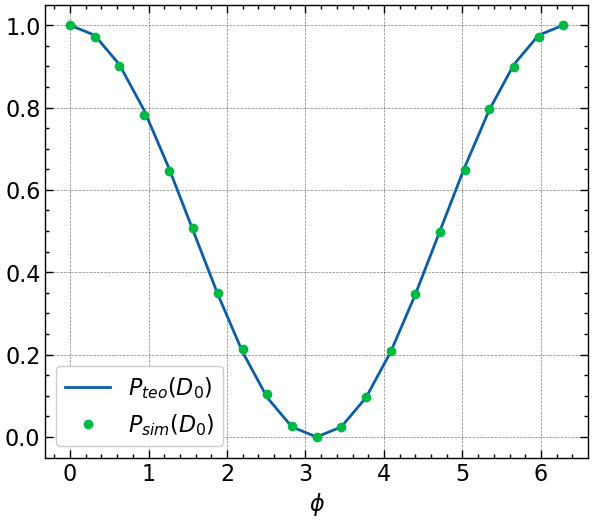

In [23]:
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

matplotlib.rcParams.update({'font.size':10}); plt.figure(figsize = (7,6), dpi = 100)
plt.plot(ph, PD0teo, label = r'$P_{teo}(D_{0})$')
plt.plot(ph, PD0sim, 'o', label = r'$P_{sim}(D_{0})$')
#plt.plot(ph, PD0exp, '*', label = r'$P_{exp}(D_{0})$')
plt.legend(); plt.xlabel(r'$\phi$'); plt.show()



### Mach-Zehnder com BS1 com $T, R$ quaisquer

De maneira geral, podemos implementar o primeiro divisor de feixes com taxa de transmissão e reflexão arbitrárias através de
\begin{equation}
U_{BS1} = U(\theta,\phi,\lambda)=\begin{bmatrix} T & iR \\ iR & T \end{bmatrix} = 
U(\theta,\phi = \pi/2,\lambda = - \pi/2),
\end{equation}
assim vemos que
\begin{align}
T = \cos(\theta/2), \ \ \ \ \ R = \sin(\theta/2) \ \ \ \ \text{tal que} \ \ \ T^2 + R^2 = 1.
\end{align}

Nesse caso, teremos que a probabilidade do fóton chegar em $D_0$ será
\begin{align}
Pr(D_0) = \frac{1}{2} + TR \cos \phi,
\end{align}
de modo que nesse caso a visibilidade será dada por
\begin{align}
V = C_{l_1}(\rho) = 2 TR.
\end{align}


In [32]:
def qc_mzig_sim(th, ph): # quantum circuit for the Mach-Zehnder interferometer
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc.u(th, math.pi/2, -math.pi/2, qr[0]); # DF
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    qc.z(qr[0]); qc.y(qr[0]) # espelho
    qc.p(ph, qr[0]); # fase
    qc.u(math.pi/2, math.pi/2, -math.pi/2, qr[0]) # DF
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    return qc
qcmzig = qc_mzig_sim(math.pi/4, math.pi/8); qcmzig.draw()



┌─────────────────┐┌───┐┌───┐┌────────┐┌─────────────────┐
q135_0: ┤ U(π/4,π/2,-π/2) ├┤ Z ├┤ Y ├┤ P(π/8) ├┤ U(π/2,π/2,-π/2) ├
        └─────────────────┘└───┘└───┘└────────┘└─────────────────┘

In [38]:
phmax = 2*math.pi; dph = phmax/20; ph = np.arange(0, phmax+dph, dph)#; ph
d = ph.shape[0]; PD0teo = np.zeros(d); PD0sim = np.zeros(d); PD0exp = np.zeros(d)
T = math.cos(math.pi/8) ### T = cos(\theta/2)
R = math.sin(math.pi/8) ### R = sin(\theta/2)

for j in range(0, d):
    PD0teo[j] = (1+2*T*R*math.cos(ph[j]))/2 # theoretical
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc_sp = state_prep(0, 0); qc.append(qc_sp, [qr[0]]) # state preparation (estado |0>)
    qc_mzig = qc_mzig_sim(math.pi/4,ph[j]); qc.append(qc_mzig, [qr[0]]) # apply sim mzi 
    qstc = state_tomography_circuits(qc, qr[0]) # circuit for state tomography
    job = qiskit.execute(qstc, Aer.get_backend('qasm_simulator'), shots=nshots)
    qstf = StateTomographyFitter(job.result(), qstc); rho = qstf.fit(method='lstsq')
    PD0sim[j] = rho[0,0].real
    # 1º fiz as simulações, só depois adicionei o código para os experimentos
    #job = qiskit.execute(qstc, backend = device, shots = nshots)
    #print(job.job_id()); job_monitor(job)
    #qstf = StateTomographyFitter(job.result(), qstc); rho = qstf.fit(method='lstsq')
    #PD0exp[j] = rho[0,0].real



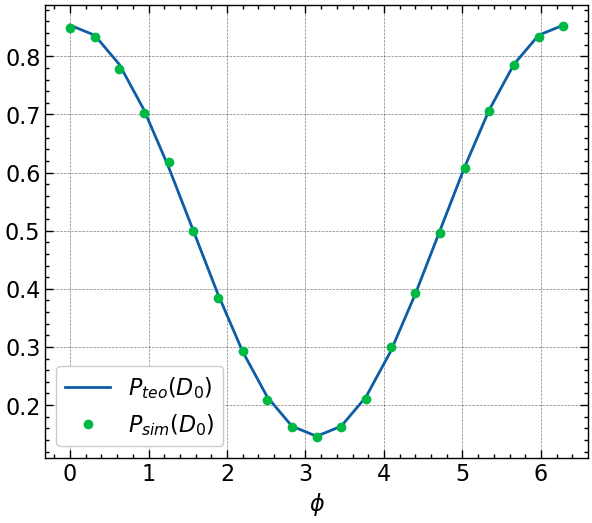

In [39]:
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

matplotlib.rcParams.update({'font.size':10}); plt.figure(figsize = (7,6), dpi = 100)
plt.plot(ph, PD0teo, label = r'$P_{teo}(D_{0})$')
plt.plot(ph, PD0sim, 'o', label = r'$P_{sim}(D_{0})$')
#plt.plot(ph, PD0exp, '*', label = r'$P_{exp}(D_{0})$')
plt.legend(); plt.xlabel(r'$\phi$'); plt.show()



### Quantum Eraser

In [5]:
def state_prep_psip():
    qr = QuantumRegister(2); qc = QuantumCircuit(qr, name = 'sprep')
    qc.h(qr[0]); qc.cx(qr[0],qr[1]); qc.x(qr[1]) # prepara psi+_01
    return qc
state_prep_psip_ = state_prep_psip(); state_prep_psip_.draw()



┌───┐          
q0_0: ┤ H ├──■───────
      └───┘┌─┴─┐┌───┐
q0_1: ─────┤ X ├┤ X ├
           └───┘└───┘

In [6]:
def qc_dfp():
    qr = QuantumRegister(2); qc = QuantumCircuit(qr, name='DFP')
    qc.cz(qr[0],qr[1]); qc.cy(qr[0], qr[1])
    return qc
qc_dfp_ = qc_dfp(); qc_dfp_.draw()



q1_0: ─■───■──
       │ ┌─┴─┐
q1_1: ─■─┤ Y ├
         └───┘

In [7]:
def qc_df():
    qr = QuantumRegister(1); qc = QuantumCircuit(qr, name='DF')
    qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0])
    return qc
qc_df_ = qc_df(); qc_df_.draw()



┌───┐┌───┐┌───┐
q2_0: ┤ S ├┤ H ├┤ S ├
      └───┘└───┘└───┘

In [8]:
def qc_pmo():
    qr = QuantumRegister(2); qc = QuantumCircuit(qr, name='PMO')
    qc.cx(qr[1],qr[0])
    return qc
qc_pmo_ = qc_pmo(); qc_pmo_.draw()

┌───┐
q3_0: ┤ X ├
      └─┬─┘
q3_1: ──■──

In [9]:
def qc_pqo():
    qr = QuantumRegister(1); qc = QuantumCircuit(qr, name='PQO')
    qc.h(qr[0]); qc.s(qr[0])
    return qc
qc_pqo_ = qc_pqo(); qc_pqo_.draw()



┌───┐┌───┐
q4_0: ┤ H ├┤ S ├
      └───┘└───┘

In [10]:
def qc_espelho():
    qr = QuantumRegister(1); qc = QuantumCircuit(qr, name='espelho')
    qc.z(qr[0]); qc.y(qr[0])
    return qc
qc_espelho_ = qc_espelho(); qc_espelho_.draw()

┌───┐┌───┐
q5_0: ┤ Z ├┤ Y ├
      └───┘└───┘

In [11]:
def qc_fase(ph):
    qr = QuantumRegister(1); qc = QuantumCircuit(qr, name='fase')
    qc.p(ph, qr[0])
    return qc
qc_fase_ = qc_fase(math.pi); qc_fase_.draw()



┌──────┐
q6_0: ┤ P(π) ├
      └──────┘

In [12]:
def qc_apagador(ph):
    qr = QuantumRegister(3); qc = QuantumCircuit(qr, name = 'apagador')
    state_prep_psip_ = state_prep_psip(); qc.append(state_prep_psip_, [qr[0],qr[1]]) # sprep
    qc_dfp_ = qc_dfp(); qc.append(qc_dfp_, [qr[1],qr[2]]) # DFP
    qc_pmo_ = qc_pmo(); qc.append(qc_pmo_, [qr[1],qr[2]]) # PMO
    qc_pqo_ = qc_pqo(); qc.append(qc_pqo_, [qr[0]]) # PQO
    qc_espelho_ = qc_espelho(); qc.append(qc_espelho_, [qr[2]]) # espelho
    qc_fase_ = qc_fase(ph); qc.append(qc_fase_, [qr[2]]) # fase
    qc_df_ = qc_df(); qc.append(qc_df_, [qr[2]]) # DF
    return qc
qc_apagador_ = qc_apagador(math.pi/3); qc_apagador_.draw()



┌────────┐┌─────┐                                  
q7_0: ┤0       ├┤ PQO ├──────────────────────────────────
      │  sprep │├─────┴┐┌──────┐                         
q7_1: ┤1       ├┤0     ├┤0     ├─────────────────────────
      └────────┘│  DFP ││  PMO │┌─────────┐┌──────┐┌────┐
q7_2: ──────────┤1     ├┤1     ├┤ espelho ├┤ fase ├┤ DF ├
                └──────┘└──────┘└─────────┘└──────┘└────┘

In [13]:
phmax = 2*math.pi; dph = phmax/20; ph = np.arange(0, phmax+dph, dph)#; ph
d = ph.shape[0]; PD0teo = np.zeros(d); PD0sim = np.zeros(d); PD0exp = np.zeros(d)
ri = random.randint(0,d)
for j in range(0, d):
    PD0teo[j] = 1/2 # theoretical
    qr = QuantumRegister(3); qc = QuantumCircuit(qr)
    qc_apagador_ = qc_apagador(ph[j]); qc.append(qc_apagador_, [qr[0],qr[1],qr[2]]) # apagador q
    qstc = state_tomography_circuits(qc, qr[2]) # circuit for state tomography
    job = qiskit.execute(qstc, Aer.get_backend('qasm_simulator'), shots=nshots)
    qstf = StateTomographyFitter(job.result(), qstc); rho = qstf.fit(method='lstsq')
    PD0sim[j] = rho[0,0].real
    if j == ri:
        print(rho)
    # 1º fiz as simulações, só depois adicionei o código para os experimentos
    '''job = qiskit.execute(qstc, backend = device, shots = nshots)
    print(job.job_id()); job_monitor(job)
    qstf = StateTomographyFitter(job.result(), qstc); rho = qstf.fit(method='lstsq')
    PD0exp[j] = rho[0,0].real'''



/home/marcos/anaconda3/lib/python3.7/site-packages/qiskit/ignis/verification/tomography/basis/circuits.py:468: DeprecationWarning: The QuantumCircuit.__iadd__() method is being deprecated. Use the compose() (potentially with the inplace=True argument) and tensor() methods which are more flexible w.r.t circuit register compatibility.
  prep += circuit
/home/marcos/anaconda3/lib/python3.7/site-packages/qiskit/circuit/quantumcircuit.py:942: DeprecationWarning: The QuantumCircuit.extend() method is being deprecated. Use the compose() (potentially with the inplace=True argument) and tensor() methods which are more flexible w.r.t circuit register compatibility.
  return self.extend(rhs)
/home/marcos/anaconda3/lib/python3.7/site-packages/qiskit/ignis/verification/tomography/basis/circuits.py:478: DeprecationWarning: The QuantumCircuit.__add__() method is being deprecated.Use the compose() method which is more flexible w.r.t circuit register compatibility.
  circ = prep + meas
/home/marcos/ana

[[ 0.49645996+0.j        -0.00354004-0.0020752j]
 [-0.00354004+0.0020752j  0.50354004+0.j       ]]


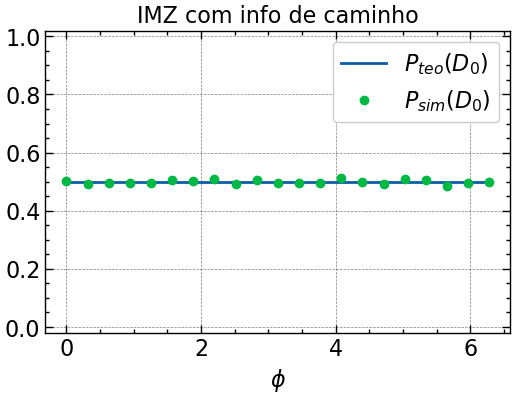

In [14]:
import matplotlib
plt.style.use(['science', 'notebook', 'grid'])    

matplotlib.rcParams.update({'font.size':12}); plt.figure(figsize = (6,4), dpi = 100)
plt.plot(ph, PD0teo, label = r'$P_{teo}(D_{0})$')
plt.plot(ph, PD0sim, 'o', label = r'$P_{sim}(D_{0})$')
#plt.plot(ph, PD0exp, '*', label = r'$P_{exp}(D_{0})$')
plt.legend(); plt.xlabel(r'$\phi$'); plt.ylim(-0.02,1.02); 
plt.title('IMZ com info de caminho'); plt.show()

### Pós-seleção

In [15]:
qr = QuantumRegister(1); cr = ClassicalRegister(1); qc = QuantumCircuit(qr,cr)
qc.h(qr[0]); qc.measure(qr[0],cr[0])
job = qiskit.execute(qc, Aer.get_backend('qasm_simulator'), shots=10)
res = job.result().get_counts()
if '0' in res:
    print('z = 0, ', res, ', ', res['0'])
elif '1' in res:
    print('z = 1, ', res, ', ', res['1'])
qc.draw()

z = 0,  {'1': 3, '0': 7} ,  7


┌───┐┌─┐
q204_0: ┤ H ├┤M├
        └───┘└╥┘
 c21: 1/══════╩═
              0

In [16]:
for j in range(0,1):
    qr = QuantumRegister(2); cr = ClassicalRegister(2); qc = QuantumCircuit(qr,cr)
    qc.h(qr[0]);
    qc.measure(qr[0],cr[0])
    qc.h(qr[1]); qc.measure(qr[1],cr[1])
    job = qiskit.execute(qc, Aer.get_backend('qasm_simulator'), shots=10)
    res = job.result().get_counts()
    print(res)
    if '00' in res:
        P00 = 1; print('P00',P00)
    elif '01' in res:
        P01 = 1; print('P01',P01)
qc.draw()



{'01': 1, '11': 5, '10': 4}
P01 1


┌───┐┌─┐   
q213_0: ┤ H ├┤M├───
        ├───┤└╥┘┌─┐
q213_1: ┤ H ├─╫─┤M├
        └───┘ ║ └╥┘
 c22: 2/══════╩══╩═
              0  1

In [17]:
# O apagador quântico mesmo, com as medidas
def apagadorM(ph):
    qr = QuantumRegister(3); cr = ClassicalRegister(2); qc = QuantumCircuit(qr, cr)
    qc_apagador_ = qc_apagador(ph); qc.append(qc_apagador_, [qr[0],qr[1],qr[2]])
    qc.measure(qr[0],cr[0]) # medida da polarização de A
    qc.measure(qr[2],cr[1]) # medida do caminho de B
    return qc
apagadorM_ = apagadorM(math.pi/8); apagadorM_.draw()



┌───────────┐┌─┐   
q222_0: ┤0          ├┤M├───
        │           │└╥┘   
q222_1: ┤1 apagador ├─╫────
        │           │ ║ ┌─┐
q222_2: ┤2          ├─╫─┤M├
        └───────────┘ ║ └╥┘
 c23: 2/══════════════╩══╩═
                      0  1

In [18]:
qc = apagadorM(math.pi/8)
job = qiskit.execute(qc, Aer.get_backend('qasm_simulator'), shots=1)
res = job.result().get_counts(); print(res)


{'11': 1}


In [19]:
nshots = 1000
phmax = 2*math.pi; dph = phmax/20; ph = np.arange(0, phmax+dph, dph); d = ph.shape[0]
PD0teo0 = np.zeros(d); PD0sim0 = np.zeros(d); PD0exp0 = np.zeros(d)
PD0teo1 = np.zeros(d); PD0sim1 = np.zeros(d); PD0exp1 = np.zeros(d)
for j in range(0, d):
    PD0teo0[j] = (1 + math.cos(ph[j]))/2; PD0teo1[j] = (1 - math.cos(ph[j]))/2
    qc = apagadorM(ph[j])
    N0 = 0; N1 = 0; N0e = 0; N1e = 0
    for k in range(0, nshots):  # não usar esse loop
        job = qiskit.execute(qc, Aer.get_backend('qasm_simulator'), shots=1)
        res = job.result().get_counts()#; print(res)
        if '00' in res or '10' in res:
            N0 += 1
        elif '01' in res or '11' in res:
            N1 += 1
        if '00' in res:
            PD0sim0[j] += 1
        elif '01' in res:
            PD0sim1[j] += 1
        '''job = qiskit.execute(qc, Aer.get_backend(device), shots=1)
        res = job.result().get_counts()
        if '00' in res or '10' in res:
            N0e += 1
        elif '01' in res or '11' in res:
            N1e += 1
        if '00' in res:
            PD0exp0[j] += 1
        elif '01' in res:
            PD0exp1[j] += 1'''
PD0sim0 = PD0sim0/N0; PD0sim1 = PD0sim1/N1
#PD0exp0 = PD0exp0/N0e; PD0exp1 = PD0exp1/N1e



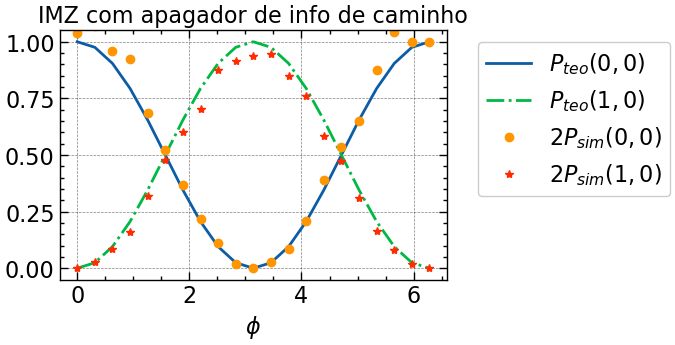

In [20]:
matplotlib.rcParams.update({'font.size':12}); plt.figure(figsize = (5,3.3), dpi = 100)
plt.plot(ph, PD0teo0, '-', label = r'$P_{teo}(0,0)$')
plt.plot(ph, PD0teo1, '-.', label = r'$P_{teo}(1,0)$')
plt.plot(ph, PD0sim0, 'o', label = r'$2P_{sim}(0,0)$')
plt.plot(ph, PD0sim1, '*', label = r'$2P_{sim}(1,0)$')
#plt.plot(ph, PD0exp0, '+', label = r'$2P_{exp}(0,0)$')
#plt.plot(ph, PD0exp1, 'd', label = r'$2P_{exp}(1,0)$')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.xlabel(r'$\phi$'); plt.ylim(-0.05,1.05); 
plt.title('IMZ com apagador de info de caminho'); plt.show()



#### Elitzur-Vaidman bomb experiment

In [2]:
from qiskit.tools.visualization import plot_histogram
from qiskit.ignis.verification.tomography import state_tomography_circuits, StateTomographyFitter
from qiskit.tools.monitor import job_monitor, backend_overview, backend_monitor


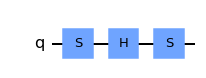

In [3]:
def qc_df():
    qc = QuantumCircuit(1, name = 'DF')
    qc.s(0); qc.h(0); qc.s(0)
    return qc
qc_df_ = qc_df(); qc_df_.draw(output = 'mpl')

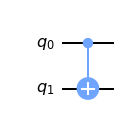

In [4]:
def qc_bomb():
    qc = QuantumCircuit(2, name = 'bomba')
    qc.cx(0,1)
    return qc
qc_bomb_ = qc_bomb(); qc_bomb_.draw(output = 'mpl')



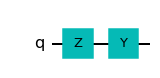

In [5]:
def qc_espelho():
    qc = QuantumCircuit(1, name = 'espelho')
    qc.z(0); qc.y(0)
    return qc
qc_espelho_ = qc_espelho(); qc_espelho_.draw(output = 'mpl')



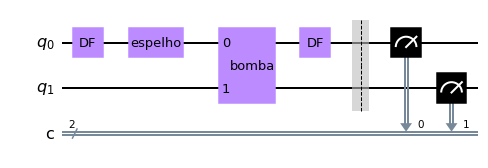

In [6]:
qc = QuantumCircuit(2, 2)
qc_df_ = qc_df(); qc.append(qc_df_, [0])
qc_espelho_ = qc_espelho(); qc.append(qc_espelho_, [0])
qc_bomb_ = qc_bomb(); qc.append(qc_bomb_, [0,1])
qc.append(qc_df_, [0]); qc.barrier()
qc.measure([0,1],[0,1])
qc.draw(output = 'mpl')



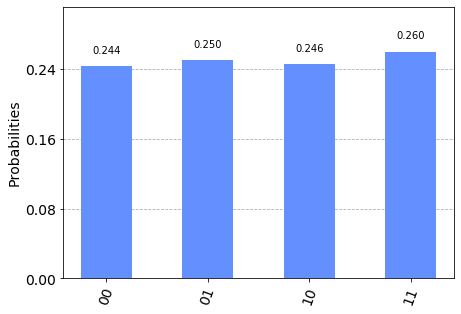

In [8]:
nshots = 8192
simulator = Aer.get_backend('qasm_simulator')
job = qiskit.execute(qc, backend = simulator, shots = nshots)
plot_histogram(job.result().get_counts(qc))



#### Elitzur-Vaiman meets Zenon

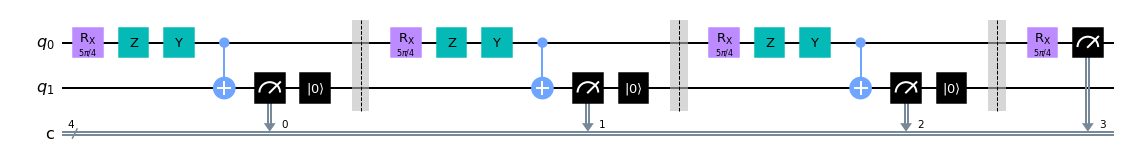

In [25]:
N = 4; th = -1*math.pi/N; qc = QuantumCircuit(2, N)
for j in range(0, N-1):
    qc.rx(math.pi - th, 0)
    qc.z(0); qc.y(0)
    qc.cx(0, 1); qc.measure(1, j); qc.reset(1)
    qc.barrier()
qc.rx(math.pi - th, 0) # o último DFG é colocado só na última volta
qc.measure(0, N-1)
qc.draw(output = 'mpl')



result = execute(qc, backend = simulator, shots = nshots).result()
plot_histogram(result.get_counts(qc))



### Mach-Zehnder Generalizado

<img src="prep1.png" width="500">



Consideremos beam-splitter $BS1$ e $BS2$ com coeficientes de transmissão e reflexão $T_1, R_1$ e $T_2, R_2$ de modo que a visibilidade neste caso é dada por
\begin{align}
V = \frac{2 R_1 R_2 T_1 T_2}{(R_1^2 T_2^2 + R_2^2 T_1^2)},
\end{align}
enquanto que a previsibilidade é dada por
\begin{align}
P = \frac{|R_1^2 T_2^2 - R_2^2 T_1^2|}{(R_1^2 T_2^2 + R_2^2 T_1^2)},
\end{align}
de modo que
\begin{align}
P^2 + V^2 = 1.
\end{align}

#### Obs:

É por isso que as relações de complementariedade usando coerência como medida de visibilidade são melhores quantificadores, como, por exemplo, $P_{vn}(\rho) + C_{re}(\rho) \le \log d.$

In [6]:
def state_prep(th, ph):
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc.u(th, ph, 0, qr[0])
    return qc



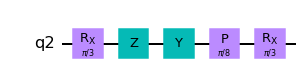

In [7]:
def qc_mzi_sim(th1,th2,ph): # quantum circuit for the Mach-Zehnder interferometer
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    qc.rx(th1, qr[0]); # DFG
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    qc.z(qr[0]); qc.y(qr[0]) # espelho
    qc.p(ph, qr[0]); # fase
    qc.rx(th2, qr[0]); # DF
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    return qc
qcmzi = qc_mzi_sim(math.pi/3, math.pi/3, math.pi/8); qcmzi.draw(output='mpl')


In [7]:
def n_basis(th, ph, typ): # general one-qubit basis
    if typ == 's': # for symbols
        ket_n0 = Matrix([[cos(th/2)],[(cos(ph)+1j*sin(ph))*sin(th/2)]])
        bra_n0 = Matrix([[cos(th/2),(cos(ph)-1j*sin(ph))*sin(th/2)]])
        ket_n1 = Matrix([[-sin(th/2)],[(cos(ph)+1j*sin(ph))*cos(th/2)]])
        bra_n1 = Matrix([[-sin(th/2),(cos(ph)-1j*sin(ph))*cos(th/2)]])
    elif typ == 'n': # for numbers
        ket_n0 = np.array([[math.cos(th/2)],[(math.cos(ph)+1j*math.sin(ph))*math.sin(th/2)]])
        bra_n0 = np.array([[math.cos(th/2),(math.cos(ph)-1j*math.sin(ph))*math.sin(th/2)]])
        ket_n1 = np.array([[-math.sin(th/2)],[(math.cos(ph)+1j*math.sin(ph))*math.cos(th/2)]])
        bra_n1 = np.array([[-math.sin(th/2),(math.cos(ph)-1j*math.sin(ph))*math.cos(th/2)]])
    return ket_n0, bra_n0, ket_n1, bra_n1

In [8]:
typ = 's' # choose to use symbols (s) or numbers (any other symbol)
if typ == 's':
    th, ph = symbols('theta phi'); ket_n0, bra_n0, ket_n1, bra_n1 = n_basis(th, ph, typ)
elif typ == 'n':
    th = math.pi/4; ph = 0; ket_n0, bra_n0, ket_n1, bra_n1 = n_basis(th, ph, typ)
ket_n0, bra_n0, ket_n1, bra_n1

⎛⎡               ⎛θ⎞            ⎤                                         ⎡   
⎜⎢            cos⎜─⎟            ⎥                                         ⎢   
⎜⎢               ⎝2⎠            ⎥  ⎡   ⎛θ⎞                          ⎛θ⎞⎤  ⎢   
⎜⎢                              ⎥, ⎢cos⎜─⎟  (-ⅈ⋅sin(φ) + cos(φ))⋅sin⎜─⎟⎥, ⎢   
⎜⎢                           ⎛θ⎞⎥  ⎣   ⎝2⎠                          ⎝2⎠⎦  ⎢   
⎜⎢(1.0⋅ⅈ⋅sin(φ) + cos(φ))⋅sin⎜─⎟⎥                                         ⎢(1.
⎝⎣                           ⎝2⎠⎦                                         ⎣   

            ⎛θ⎞            ⎤                                        ⎞
        -sin⎜─⎟            ⎥                                        ⎟
            ⎝2⎠            ⎥  ⎡    ⎛θ⎞                          ⎛θ⎞⎤⎟
                           ⎥, ⎢-sin⎜─⎟  (-ⅈ⋅sin(φ) + cos(φ))⋅cos⎜─⎟⎥⎟
                        ⎛θ⎞⎥  ⎣    ⎝2⎠                          ⎝2⎠⎦⎟
0⋅ⅈ⋅sin(φ) + cos(φ))⋅cos⎜─⎟⎥                                        ⎟
                        ⎝2

In [9]:
def rho_basis_n(th, ph, rho, typ): # representation of rho in a given basis
    ket_n0, bra_n0, ket_n1, bra_n1 = n_basis(th, ph, typ)
    if typ == 's':
        rhon = Matrix([[bra_n0*rho*ket_n0, bra_n0*rho*ket_n1],[bra_n1*rho*ket_n0, bra_n1*rho*ket_n1]])
    elif typ == 'n':
        rho00 = bra_n0.dot(rho.dot(ket_n0)); rho01 = bra_n0.dot(rho.dot(ket_n1))
        rho10 = bra_n1.dot(rho.dot(ket_n0)); rho11 = bra_n1.dot(rho.dot(ket_n1))
        rhon = np.array([[rho00.item(), rho01.item()],[rho10.item(), rho11.item()]])
    return rhon

In [10]:
def predictability_vn(rho, th, ph): # th,ph define the reference basis
    d = rho.shape[0]; 
    # matrix rep. of rho in the basis def. by (th,ph)
    rhon = rho_basis_n(th, ph, rho, 'n');# print('rhon = ',rhon)
    pv = np.zeros(d); 
    for j in range(0,d):
        pv[j] = rhon[j,j].real
    return log(d, 2) - shannon_num(pv)

In [11]:
def coherence_re(rho, th, ph): # th,ph defines the reference basis
    d = rho.shape[0]; pv = np.zeros(d)
    # matrix representation of rho in the basis defined by (th,ph)
    rhon = rho_basis_n(th, ph, rho, 'n'); #print(rhon)
    for j in range(0, d):
        pv[j] = rhon[j,j].real
    # we use the same state to compute S_vn because of its basis invariance
    return shannon_num(pv) - von_neumann_num(rho)

In [14]:
import math
def vis(th,ph):
    return 2*math.cos(th)*math.sin(th)*math.cos(ph)*math.sin(ph)/(math.cos(th)**2*math.sin(ph)**2 + math.cos(ph)**2*math.sin(th)**2)

In [21]:
import math
th_min = 0; th_max = math.pi/2; N = 10; dth = (th_max-th_min)/N; th = dth + 10**-4; thv = np.zeros(N+1)
ph_min = 0; ph_max = math.pi; dph = ph_max - ph_min, ph = dph + 10**-4
Cresim = np.zeros(N+1); Pvnsim = np.zeros(N+1); Vis = np.zeros(N+1)
for j in range(0, N+1):
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    th += dth
    thv[j] = th 
    qc.rx(-2*th, qr[0]); # DFG
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    qc.z(qr[0]); qc.y(qr[0]) # espelho
    qc.p(2*np.pi/7, qr[0]); # fase

    qstc = state_tomography_circuits(qc, qr[0]) # circuit for state tomography
    job_dev = qiskit.execute(qstc,  backend = device, shots = 8192); # executes the qst
    print(job_dev.job_id());
    job_monitor(job_dev);    
    job_dev_mit = meas_filter.apply(job_dev.result(), method='least_squares'); # error mitigation
    qstc_dev = StateTomographyFitter(job_dev_mit, qstc); # fits the data to extract rho
    rho = qstc_dev.fit(method='lstsq'); 
   
        
    Cresim[j] = coherence_re(rho, 0, 0)
    Pvnsim[j] = predictability_vn(rho, 0, 0)
    
    qc.rx(-2*th, qr[0]); # DFG

    Vis[j] = vis(th,th)

6241e6bbab930702a5386a35
Job Status: job has successfully run
6241e729ab93079aea386a38
Job Status: job has successfully run
6241e77998d40b80f9d975ae
Job Status: job has successfully run
6241e7fb98d40b87d9d975b1
Job Status: job has successfully run
6241e84b885fa267f11739df
Job Status: job has successfully run
6241e8a5ab9307d261386a3f
Job Status: job has successfully run
6241e91e98d40bc8a7d975b6
Job Status: job has successfully run
6241e96c934a92516e32e251
Job Status: job has successfully run
6241e9befb239424af9a654b
Job Status: job has successfully run
6241ea18ab930792e1386a4a
Job Status: job has successfully run
6241ea72fee6e509e85f0ae1
Job Status: job has successfully run


In [ ]:
import math
th_min = 0; th_max = math.pi/2; N = 10; dth = (th_max-th_min)/N; th = dth + 10**-4; thv = np.zeros(N+1)
ph_min = 0; ph_max = math.pi; dph = ph_max - ph_min, ph = dph + 10**-4
Cresim = np.zeros(N+1); Pvnsim = np.zeros(N+1); Vis = np.zeros(N+1)
for j in range(0, N+1):
    
    qr = QuantumRegister(1); qc = QuantumCircuit(qr)
    th += dth
    thv[j] = th 
    qc.rx(-2*th, qr[0]); # DFG
    #qc.s(qr[0]); qc.h(qr[0]); qc.s(qr[0]) # DF
    qc.z(qr[0]); qc.y(qr[0]) # espelho
    qc.p(2*np.pi/7, qr[0]); # fase

    qstc = state_tomography_circuits(qc, qr[0]) # circuit for state tomography
    job_dev = qiskit.execute(qstc,  backend = device, shots = 8192); # executes the qst
    print(job_dev.job_id());
    job_monitor(job_dev);    
    job_dev_mit = meas_filter.apply(job_dev.result(), method='least_squares'); # error mitigation
    qstc_dev = StateTomographyFitter(job_dev_mit, qstc); # fits the data to extract rho
    rho = qstc_dev.fit(method='lstsq'); 

    
    qc.rx(-2*th, qr[0]); # DFG

    Vis[j] = vis(th,th)

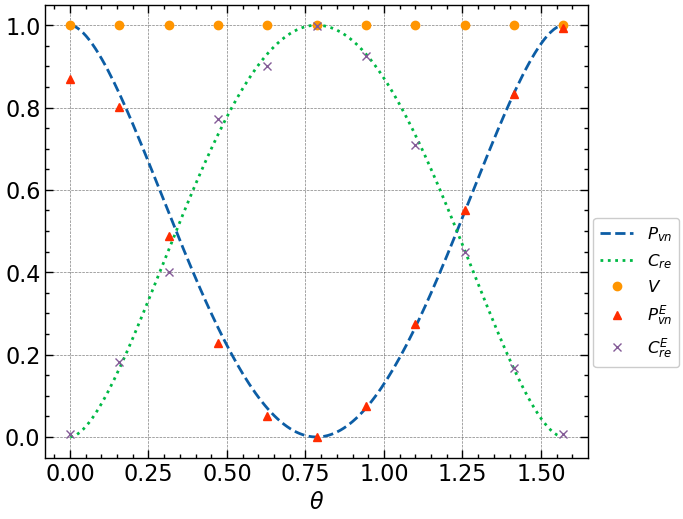

In [22]:
import matplotlib
import numpy as np
plt.style.use(['science', 'notebook', 'grid'])    
x = np.arange(0.001, np.pi/2, 0.01)    

Cre = -np.cos(x)**2*np.log2(np.cos(x)**2) - (1-np.cos(x)**2)*np.log2(1-np.cos(x)**2)
Pvn = 1 - Cre

matplotlib.rcParams.update({'font.size':10}); plt.figure(figsize = (7,6), dpi = 100)
plt.plot(x, Pvn, '--',label = r'$P_{vn}$')
plt.plot(x, Cre, ':', label = r'$C_{re}$')
plt.plot(thv, Vis, 'o', label = r'$V$')
plt.plot(thv, Pvnsim, '^', label = r'$P_{vn}^E$')
plt.plot(thv, Cresim, 'x', label = r'$C_{re}^E$')

plt.xlabel(r'$\theta$'); 
    #plt.legend(loc = 'center right', bbox_to_anchor=(th_max-0.05, 0.5))
plt.legend(fontsize=12, loc=(1.01,0.2) )
    #plt.savefig(path+'psi_plot1.png', format = 'png', dpi = 200)
plt.savefig('visexp.pdf', format='pdf',dpi = 1200, bbox_inches='tight')

plt.show()
